# Part 1: Data Collection and Preprocessing

This notebook downloads SVG datasets, cleans and normalizes them, trains a BPE tokenizer, splits the data, and saves everything needed for later parts.

All outputs are saved to a `ml_final_project/` folder. Update `PROJECT_DIR` in the config cell to match your HPC path.


In [1]:
!pip install datasets lxml tokenizers matplotlib numpy tqdm -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import os
import re
import json
import random
import shutil
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from lxml import etree
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter
from datasets import load_dataset

# UPDATE THIS PATH to your HPC project directory
PROJECT_DIR = Path("ml_final_project")

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = PROJECT_DIR / "plots"
EXAMPLES_DIR = OUTPUT_DIR / "example_svgs"

MAX_TOKEN_LEN = 1024
MIN_CHAR_LEN = 50
VOCAB_SIZE = 4096
SEED = 42
TRAIN_FRAC = 0.98
VAL_FRAC = 0.01
TEST_FRAC = 0.01
TARGET_MIN_TOKENS = 100_000_000
FONTS_SUBSAMPLE = 200_000

for d in [DATA_DIR, OUTPUT_DIR, PLOT_DIR, EXAMPLES_DIR]:
    d.mkdir(exist_ok=True, parents=True)

random.seed(SEED)
np.random.seed(SEED)

print("Config ready")
print(f"  Project directory: {PROJECT_DIR.resolve()}")
print(f"  Vocab size: {VOCAB_SIZE}")
print(f"  Max token length: {MAX_TOKEN_LEN}")
print(f"  Target min train tokens: {TARGET_MIN_TOKENS:,}")

Config ready
  Project directory: /scratch/ds8223/ml_final_project/ml_final_project
  Vocab size: 4096
  Max token length: 1024
  Target min train tokens: 100,000,000


## Step 1: Download Datasets

In [3]:
def get_svg_text(dataset, source_name):
    svgs = []
    if isinstance(dataset, list):
        cols = list(dataset[0].keys()) if dataset else []
    else:
        cols = dataset.column_names

    svg_col = None
    for candidate in ['Svg', 'svg', 'code', 'svg_code', 'text', 'content']:
        if candidate in cols:
            svg_col = candidate
            break
    if svg_col is None and cols:
        svg_col = cols[0]
    print(f"  Using column '{svg_col}' from {source_name}")

    for item in dataset:
        val = item[svg_col] if isinstance(item, dict) else item
        if isinstance(val, str):
            svgs.append((val, source_name))
    return svgs

print("Loading svg icons simple...")
ds_icons = load_dataset("starvector/svg-icons-simple", split="train")
print(f"  Got {len(ds_icons)} samples")

print("Loading svg emoji simple...")
ds_emoji = load_dataset("starvector/svg-emoji-simple", split="train")
print(f"  Got {len(ds_emoji)} samples")

print(f"Loading svg fonts simple (streaming, taking {FONTS_SUBSAMPLE:,})...")
ds_fonts_stream = load_dataset("starvector/svg-fonts-simple", split="train", streaming=True)
fonts_list = []
for i, item in enumerate(tqdm(ds_fonts_stream, total=FONTS_SUBSAMPLE, desc="Downloading fonts")):
    if i >= FONTS_SUBSAMPLE:
        break
    fonts_list.append(item)
print(f"  Got {len(fonts_list)} samples")

all_svgs = []
all_svgs.extend(get_svg_text(ds_icons, "icons"))
all_svgs.extend(get_svg_text(ds_emoji, "emoji"))
all_svgs.extend(get_svg_text(fonts_list, "fonts"))

# Uncomment below if you need more data to hit 100M tokens
# print("Loading svg stack simple (streaming, taking 300K)...")
# ds_stack = load_dataset("starvector/svg-stack-simple", split="train", streaming=True)
# stack_list = []
# for i, item in enumerate(tqdm(ds_stack, total=300_000)):
#     if i >= 300_000: break
#     stack_list.append(item)
# all_svgs.extend(get_svg_text(stack_list, "stack"))

print(f"\nTotal raw SVGs collected: {len(all_svgs)}")

Loading svg icons simple...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/646 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/346 [00:00<?, ? examples/s]

  Got 4114 samples
Loading svg fonts simple (streaming, taking 200,000)...


README.md: 0.00B [00:00, ?B/s]

  Got 200000 samples
  Using column 'Svg' from icons
  Using column 'Svg' from emoji
  Using column 'Svg' from fonts

Total raw SVGs collected: 284548


## Step 2: Clean and Normalize SVGs

In [4]:
def round_coordinates(svg_text, precision=1):
    def round_match(m):
        try:
            val = float(m.group(0))
            rounded = round(val, precision)
            if rounded == int(rounded):
                return str(int(rounded))
            return f"{rounded:.{precision}f}"
        except ValueError:
            return m.group(0)
    return re.sub(r'(?<=[=\s,"\'\;:])(-?\d+\.\d{2,})', round_match, svg_text)

def normalize_svg(svg_text):
    if not svg_text or not isinstance(svg_text, str):
        return None
    svg_text = svg_text.strip()
    svg_start = svg_text.find('<svg')
    if svg_start == -1:
        return None
    svg_text = svg_text[svg_start:]
    svg_text = re.sub(r'<!--.*?-->', '', svg_text, flags=re.DOTALL)
    svg_text = re.sub(r'\s+', ' ', svg_text)
    svg_text = re.sub(r'<metadata[^>]*>.*?</metadata>', '', svg_text, flags=re.DOTALL|re.IGNORECASE)
    svg_text = re.sub(r'<title[^>]*>.*?</title>', '', svg_text, flags=re.DOTALL|re.IGNORECASE)
    svg_text = re.sub(r'<desc[^>]*>.*?</desc>', '', svg_text, flags=re.DOTALL|re.IGNORECASE)
    svg_text = round_coordinates(svg_text, precision=1)
    return svg_text.strip()

def validate_xml(svg_text):
    try:
        etree.fromstring(svg_text.encode('utf-8'))
        return True
    except:
        return False

cleaning_stats = {"total_raw": len(all_svgs), "failed_normalize": 0,
                  "too_short": 0, "invalid_xml": 0, "passed": 0, "source_counts": Counter()}
cleaned_svgs = []

for svg_text, source in tqdm(all_svgs, desc="Cleaning SVGs"):
    normed = normalize_svg(svg_text)
    if normed is None:
        cleaning_stats["failed_normalize"] += 1
        continue
    if len(normed) < MIN_CHAR_LEN:
        cleaning_stats["too_short"] += 1
        continue
    if not validate_xml(normed):
        cleaning_stats["invalid_xml"] += 1
        continue
    cleaned_svgs.append((normed, source))
    cleaning_stats["passed"] += 1
    cleaning_stats["source_counts"][source] += 1

print(f"\nCleaning complete")
print(f"  Started with {cleaning_stats['total_raw']:,} SVGs")
print(f"  Passed: {cleaning_stats['passed']:,}")
print(f"  Failed to normalize: {cleaning_stats['failed_normalize']:,}")
print(f"  Too short: {cleaning_stats['too_short']:,}")
print(f"  Invalid XML: {cleaning_stats['invalid_xml']:,}")
print(f"  By source: {dict(cleaning_stats['source_counts'])}")

Cleaning SVGs:   0%|          | 0/284548 [00:00<?, ?it/s]


Cleaning complete
  Started with 284,548 SVGs
  Passed: 284,548
  Failed to normalize: 0
  Too short: 0
  Invalid XML: 0
  By source: {'icons': 80434, 'emoji': 4114, 'fonts': 200000}


## Step 3: Train BPE Tokenizer

In [5]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

corpus_path = DATA_DIR / "svg_corpus.txt"
print(f"Writing corpus with {len(cleaned_svgs):,} SVGs...")
with open(corpus_path, "w", encoding="utf-8") as f:
    for svg_text, _ in cleaned_svgs:
        f.write(svg_text + "\n")

tokenizer = Tokenizer(models.BPE(unk_token="<UNK>"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=["<PAD>", "<BOS>", "<EOS>", "<UNK>"],
    min_frequency=2,
    show_progress=True,
)

print(f"Training BPE tokenizer with vocab size {VOCAB_SIZE}...")
tokenizer.train([str(corpus_path)], trainer)
tokenizer.save(str(DATA_DIR / "svg_tokenizer.json"))

print(f"Done. Final vocab size: {tokenizer.get_vocab_size()}")

sample = cleaned_svgs[0][0][:200]
enc = tokenizer.encode(sample)
print(f"\nSanity check")
print(f"  Sample text: {sample[:80]}...")
print(f"  Encoded to {len(enc.ids)} tokens")

Writing corpus with 284,548 SVGs...
Training BPE tokenizer with vocab size 4096...



Done. Final vocab size: 4096

Sanity check
  Sample text: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200p...
  Encoded to 79 tokens


## Step 4: Tokenize, Filter, and Split

In [6]:
tokenized = []
filtered_long = 0
token_lengths = []

for svg_text, source in tqdm(cleaned_svgs, desc="Tokenizing"):
    enc = tokenizer.encode(svg_text)
    tlen = len(enc.ids)
    if tlen > MAX_TOKEN_LEN:
        filtered_long += 1
        continue
    tokenized.append({"text": svg_text, "token_ids": enc.ids, "token_len": tlen, "source": source})
    token_lengths.append(tlen)

random.shuffle(tokenized)
n = len(tokenized)
n_val = max(1, int(n * VAL_FRAC))
n_test = max(1, int(n * TEST_FRAC))
n_train = n - n_val - n_test

train_set = tokenized[:n_train]
val_set = tokenized[n_train:n_train+n_val]
test_set = tokenized[n_train+n_val:]

train_tokens = sum(i["token_len"] for i in train_set)
val_tokens = sum(i["token_len"] for i in val_set)
test_tokens = sum(i["token_len"] for i in test_set)

print(f"\nTokenization complete")
print(f"  Filtered out (over {MAX_TOKEN_LEN} tokens): {filtered_long:,}")
print(f"  Kept: {len(tokenized):,}")
print(f"  Train: {len(train_set):,} files, {train_tokens:,} tokens")
print(f"  Val: {len(val_set):,} files, {val_tokens:,} tokens")
print(f"  Test: {len(test_set):,} files, {test_tokens:,} tokens")

if train_tokens < TARGET_MIN_TOKENS:
    print(f"  Below 100M target. Increase FONTS_SUBSAMPLE or add svg stack simple.")
else:
    print(f"  Meets 100M token target")

Tokenizing:   0%|          | 0/284548 [00:00<?, ?it/s]


Tokenization complete
  Filtered out (over 1024 tokens): 48,019
  Kept: 236,529
  Train: 231,799 files, 115,916,260 tokens
  Val: 2,365 files, 1,176,658 tokens
  Test: 2,365 files, 1,186,563 tokens
  Meets 100M token target


## Step 5: Save Splits and Statistics

In [7]:
bos_id = tokenizer.token_to_id("<BOS>")
eos_id = tokenizer.token_to_id("<EOS>")

for name, split in [("train", train_set), ("val", val_set), ("test", test_set)]:
    # Save JSONL
    with open(DATA_DIR / f"{name}.jsonl", "w") as f:
        for item in split:
            json.dump({"text": item["text"], "token_ids": item["token_ids"], "source": item["source"]}, f)
            f.write("\n")

    # Save binary
    all_ids = []
    for item in split:
        if bos_id is not None:
            all_ids.append(bos_id)
        all_ids.extend(item["token_ids"])
        if eos_id is not None:
            all_ids.append(eos_id)
    arr = np.array(all_ids, dtype=np.uint16)
    arr.tofile(str(DATA_DIR / f"{name}.bin"))
    print(f"  Saved {name}: {len(arr):,} tokens, {arr.nbytes/1e6:.1f} MB")

# Statistics
token_lengths_arr = np.array(token_lengths)
dataset_stats = {
    "vocab_size": tokenizer.get_vocab_size(),
    "files_before_filtering": cleaning_stats["total_raw"],
    "files_after_cleaning": cleaning_stats["passed"],
    "files_after_token_filter": len(tokenized),
    "num_files": {"train": len(train_set), "val": len(val_set), "test": len(test_set)},
    "num_tokens": {"train": train_tokens, "val": val_tokens, "test": test_tokens},
    "seq_len_stats": {
        "mean": float(token_lengths_arr.mean()),
        "median": float(np.median(token_lengths_arr)),
        "std": float(token_lengths_arr.std()),
        "min": int(token_lengths_arr.min()),
        "max": int(token_lengths_arr.max()),
        "p25": float(np.percentile(token_lengths_arr, 25)),
        "p75": float(np.percentile(token_lengths_arr, 75)),
        "p95": float(np.percentile(token_lengths_arr, 95)),
    },
}
with open(OUTPUT_DIR / "dataset_statistics.json", "w") as f:
    json.dump(dataset_stats, f, indent=2)

print(f"\nDataset statistics saved")
print(json.dumps(dataset_stats, indent=2))

  Saved train: 116,379,858 tokens, 232.8 MB
  Saved val: 1,181,388 tokens, 2.4 MB
  Saved test: 1,191,293 tokens, 2.4 MB

Dataset statistics saved
{
  "vocab_size": 4096,
  "files_before_filtering": 284548,
  "files_after_cleaning": 284548,
  "files_after_token_filter": 236529,
  "num_files": {
    "train": 231799,
    "val": 2365,
    "test": 2365
  },
  "num_tokens": {
    "train": 115916260,
    "val": 1176658,
    "test": 1186563
  },
  "seq_len_stats": {
    "mean": 500.0633368424168,
    "median": 475.0,
    "std": 198.81460989452523,
    "min": 93,
    "max": 1024,
    "p25": 354.0,
    "p75": 622.0,
    "p95": 889.0
  }
}


## Step 6: Sequence Length Histogram

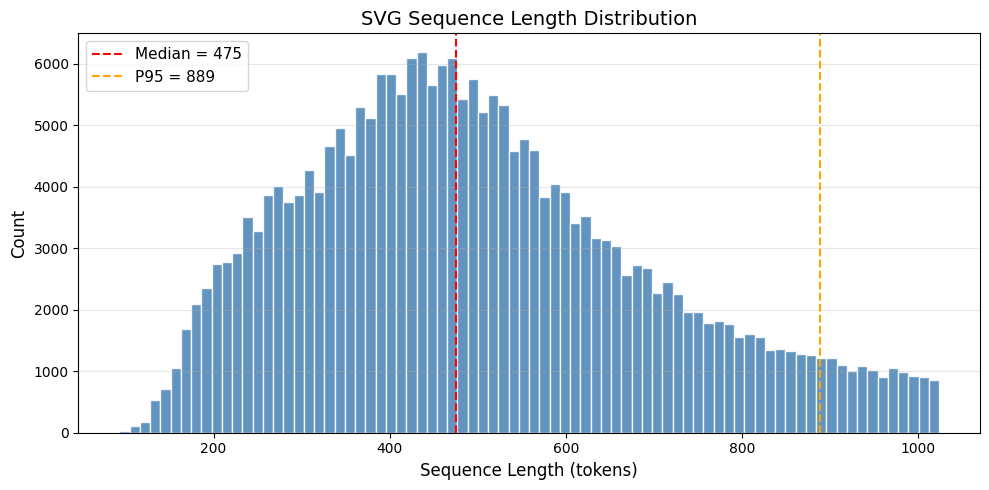

Histogram saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(token_lengths_arr, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel("Sequence Length (tokens)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("SVG Sequence Length Distribution", fontsize=14)
ax.axvline(np.median(token_lengths_arr), color='red', linestyle='--',
           label=f'Median = {np.median(token_lengths_arr):.0f}')
ax.axvline(np.percentile(token_lengths_arr, 95), color='orange', linestyle='--',
           label=f'P95 = {np.percentile(token_lengths_arr, 95):.0f}')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "seq_length_histogram.png"), dpi=150)
plt.show()
print("Histogram saved")

## Step 7: Example SVGs at Different Complexity Levels

Percentile 5: example_p5_len211.svg with 211 tokens


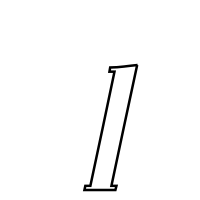

Percentile 25: example_p25_len354.svg with 354 tokens


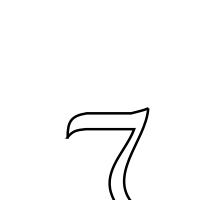

Percentile 50: example_p50_len475.svg with 475 tokens


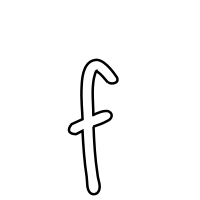

Percentile 75: example_p75_len622.svg with 622 tokens


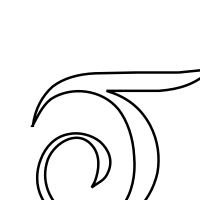

Percentile 95: example_p95_len888.svg with 888 tokens


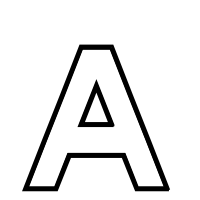


All example SVGs saved


In [9]:
from IPython.display import SVG, display, HTML

sorted_by_len = sorted(train_set, key=lambda x: x["token_len"])
n_ex = len(sorted_by_len)

for p in [5, 25, 50, 75, 95]:
    idx = min(int(n_ex * p / 100), n_ex - 1)
    item = sorted_by_len[idx]
    fname = f"example_p{p}_len{item['token_len']}.svg"
    with open(EXAMPLES_DIR / fname, "w") as f:
        f.write(item["text"])
    print(f"Percentile {p}: {fname} with {item['token_len']} tokens")
    try:
        display(SVG(data=item["text"]))
    except:
        display(HTML(f'<div style="border:1px solid #ccc;padding:10px;max-width:300px">{item["text"]}</div>'))

print("\nAll example SVGs saved")

## Part 1 Complete

In [10]:
print("Part 1 finished. Files saved to", PROJECT_DIR.resolve())
print("")
print("Files you need for later parts:")
print(f"  {DATA_DIR / 'train.bin'}")
print(f"  {DATA_DIR / 'val.bin'}")
print(f"  {DATA_DIR / 'test.bin'}")
print(f"  {DATA_DIR / 'svg_tokenizer.json'}")
print("")
print("Files for the report:")
print(f"  {OUTPUT_DIR / 'dataset_statistics.json'}")
print(f"  {PLOT_DIR / 'seq_length_histogram.png'}")
print(f"  {EXAMPLES_DIR}")

Part 1 finished. Files saved to /scratch/ds8223/ml_final_project/ml_final_project

Files you need for later parts:
  ml_final_project/data/train.bin
  ml_final_project/data/val.bin
  ml_final_project/data/test.bin
  ml_final_project/data/svg_tokenizer.json

Files for the report:
  ml_final_project/outputs/dataset_statistics.json
  ml_final_project/plots/seq_length_histogram.png
  ml_final_project/outputs/example_svgs
